In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
# Загрузить датасет. Сколько всего пропущенных значений?
# Посмотреть: какие значения есть в колонке transaction. Cколько раз встречается каждое значение
# Посчитать количество транзакций со статусом error
# Считать только successfull. Для каждого пользователя определить количество успешных транзакций. изучить распределение (describe()). Построить гистограмму
# Использовать обновленный датасет. Фильтровать успешные транзакции НЕ нужно.
# Создать колонку true_minute где должно храниться: количество минут, прошедших с начала дня.


In [3]:
df = pd.read_csv('5_transaction_data.csv', parse_dates=['date'])

df.head(5)

,date,name,transaction
0,2020-03-02 00:37:20,Ekaterina_Petrova,cancelled
1,2020-03-02 00:59:09,Irina_Fedorova,successfull
2,2020-03-02 01:06:14,Ekaterina_Smirnova,successfull
3,2020-03-02 00:02:58,Lolita_Polyanova,cancelled
4,2020-03-02 00:17:52,Julia_Smirnova,cancelled


In [4]:
df.dtypes

date           datetime64[us]
name                      str
transaction               str
dtype: object

In [5]:
df.shape

(5315, 3)

In [6]:
df.isna().sum()

date           0
name           0
transaction    0
dtype: int64

In [7]:
df.describe()

,date
count,5315
mean,2020-03-02 00:43:56.628974
min,2020-03-02 00:00:00
25%,2020-03-02 00:21:50.500000
50%,2020-03-02 00:43:26
75%,2020-03-02 01:06:22.500000
max,2020-03-02 01:29:05


In [8]:
transaction_counts = df['transaction'].value_counts().reset_index()
transaction_counts

,transaction,count
0,successfull,3692
1,cancelled,1619
2,error,4


Text(0.5, 1.0, 'Распределение по типам транзакций')

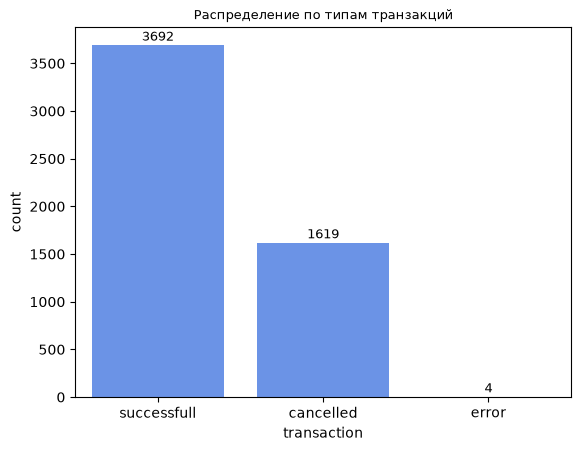

In [9]:
ax = sns.barplot(data=transaction_counts, x= 'transaction', y= 'count')

ax.bar_label(ax.containers[0], padding=1, fontsize=9)
ax.set_title('Распределение по типам транзакций', fontsize=9)

In [10]:
user_transactions = df.query('transaction == "successfull"').groupby('name',as_index=False).transaction.count()

user_transactions

,name,transaction
0,Ekaterina_Fedorova,72
1,Ekaterina_Ivanova,59
2,Ekaterina_Lesnova,63
3,Ekaterina_Ozerova,72
4,Ekaterina_Petrova,68
5,Ekaterina_Polyanova,68
6,Ekaterina_Smirnova,77
7,Irina_Fedorova,62
8,Irina_Ivanova,60
9,Irina_Lesnova,76


In [11]:
user_transactions.describe()

,transaction
count,56.000000
mean,65.928571
std,7.787769
min,46.000000
25%,61.000000
50%,64.000000
75%,72.000000
max,82.000000


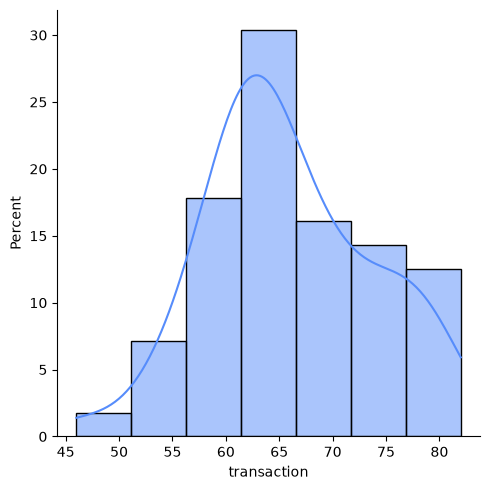

In [12]:
sns.displot(x= user_transactions.transaction, kde=True, stat = 'percent')

In [13]:
df_updated = pd.read_csv('5_transaction_data_updated.csv', parse_dates=['date'])
df_updated.head()

,date,name,transaction,minute
0,2020-03-02 00:37:20,Ekaterina_Petrova,cancelled,37
1,2020-03-02 00:59:09,Irina_Fedorova,successfull,59
2,2020-03-02 01:06:14,Ekaterina_Smirnova,successfull,6
3,2020-03-02 00:02:58,Lolita_Polyanova,cancelled,2
4,2020-03-02 00:17:52,Julia_Smirnova,cancelled,17


In [14]:
df_updated.dtypes

date           datetime64[us]
name                      str
transaction               str
minute                  int64
dtype: object

In [15]:
user_vs_minute_pivot = df_updated.pivot_table(index='minute', columns='name', values='transaction', aggfunc = 'count').reset_index().fillna(0)
user_vs_minute_pivot

name,minute,Ekaterina_Fedorova,Ekaterina_Ivanova,Ekaterina_Lesnova,Ekaterina_Ozerova,Ekaterina_Petrova,Ekaterina_Polyanova,Ekaterina_Smirnova,Irina_Fedorova,Irina_Ivanova,...,Svetlana_Petrova,Svetlana_Polyanova,Svetlana_Smirnova,Vasilisa_Fedorova,Vasilisa_Ivanova,Vasilisa_Lesnova,Vasilisa_Ozerova,Vasilisa_Petrova,Vasilisa_Polyanova,Vasilisa_Smirnova
0,0,3.0,4.0,2.0,3.0,4.0,4.0,2.0,1.0,2.0,...,0.0,3.0,1.0,1.0,4.0,1.0,3.0,0.0,0.0,1.0
1,1,4.0,4.0,0.0,4.0,2.0,5.0,4.0,4.0,4.0,...,4.0,5.0,3.0,2.0,3.0,3.0,0.0,0.0,3.0,2.0
2,2,1.0,2.0,4.0,4.0,2.0,1.0,3.0,2.0,3.0,...,4.0,1.0,3.0,3.0,0.0,1.0,2.0,1.0,3.0,1.0
3,3,3.0,0.0,2.0,0.0,5.0,2.0,1.0,3.0,2.0,...,1.0,5.0,5.0,2.0,4.0,0.0,3.0,4.0,1.0,0.0
4,4,3.0,0.0,0.0,3.0,1.0,1.0,2.0,3.0,2.0,...,1.0,2.0,2.0,1.0,1.0,2.0,2.0,3.0,0.0,1.0
5,5,3.0,0.0,2.0,3.0,1.0,0.0,5.0,3.0,1.0,...,0.0,2.0,3.0,1.0,0.0,0.0,3.0,0.0,2.0,1.0
6,6,4.0,1.0,2.0,2.0,0.0,4.0,5.0,2.0,2.0,...,2.0,1.0,4.0,1.0,2.0,4.0,1.0,2.0,0.0,2.0
7,7,3.0,2.0,1.0,2.0,2.0,3.0,4.0,1.0,1.0,...,3.0,1.0,1.0,2.0,4.0,1.0,0.0,1.0,2.0,2.0
8,8,2.0,4.0,3.0,1.0,0.0,3.0,2.0,1.0,1.0,...,0.0,1.0,0.0,1.0,2.0,4.0,2.0,1.0,1.0,1.0
9,9,2.0,4.0,2.0,3.0,4.0,0.0,3.0,2.0,2.0,...,2.0,3.0,1.0,2.0,4.0,2.0,3.0,0.0,1.0,4.0


In [16]:
df_updated ['true_minute'] = (df_updated.date.dt.hour * 60) + df_updated.date.dt.minute
df_updated.head(6)

,date,name,transaction,minute,true_minute
0,2020-03-02 00:37:20,Ekaterina_Petrova,cancelled,37,37
1,2020-03-02 00:59:09,Irina_Fedorova,successfull,59,59
2,2020-03-02 01:06:14,Ekaterina_Smirnova,successfull,6,66
3,2020-03-02 00:02:58,Lolita_Polyanova,cancelled,2,2
4,2020-03-02 00:17:52,Julia_Smirnova,cancelled,17,17
5,2020-03-02 01:09:55,Irina_Polyanova,cancelled,9,69


In [17]:
minute_pivot = df_updated.pivot_table(index='true_minute', columns='name', values='transaction', aggfunc = 'count').reset_index().fillna(0)
minute_pivot

name,true_minute,Ekaterina_Fedorova,Ekaterina_Ivanova,Ekaterina_Lesnova,Ekaterina_Ozerova,Ekaterina_Petrova,Ekaterina_Polyanova,Ekaterina_Smirnova,Irina_Fedorova,Irina_Ivanova,...,Svetlana_Petrova,Svetlana_Polyanova,Svetlana_Smirnova,Vasilisa_Fedorova,Vasilisa_Ivanova,Vasilisa_Lesnova,Vasilisa_Ozerova,Vasilisa_Petrova,Vasilisa_Polyanova,Vasilisa_Smirnova
0,0,1.0,3.0,0.0,1.0,3.0,3.0,2.0,1.0,1.0,...,0.0,2.0,0.0,0.0,2.0,1.0,3.0,0.0,0.0,1.0
1,1,1.0,4.0,0.0,3.0,2.0,1.0,3.0,1.0,2.0,...,2.0,4.0,3.0,1.0,2.0,1.0,0.0,0.0,2.0,0.0
2,2,1.0,1.0,2.0,3.0,1.0,0.0,2.0,1.0,1.0,...,2.0,0.0,2.0,3.0,0.0,0.0,1.0,1.0,3.0,1.0
3,3,2.0,0.0,1.0,0.0,3.0,1.0,1.0,2.0,1.0,...,0.0,2.0,2.0,0.0,4.0,0.0,1.0,2.0,1.0,0.0
4,4,2.0,0.0,0.0,2.0,1.0,1.0,1.0,3.0,1.0,...,1.0,1.0,1.0,0.0,0.0,2.0,1.0,2.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,85,4.0,0.0,2.0,1.0,1.0,1.0,0.0,1.0,0.0,...,2.0,2.0,1.0,2.0,0.0,1.0,1.0,2.0,1.0,1.0
86,86,0.0,1.0,0.0,0.0,2.0,1.0,2.0,1.0,0.0,...,0.0,0.0,0.0,2.0,1.0,1.0,0.0,0.0,1.0,1.0
87,87,3.0,1.0,0.0,2.0,2.0,3.0,0.0,0.0,0.0,...,1.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0
88,88,0.0,1.0,0.0,1.0,1.0,0.0,1.0,4.0,1.0,...,1.0,1.0,3.0,2.0,2.0,0.0,0.0,2.0,2.0,3.0


In [18]:
new_transaction = df_updated.groupby('true_minute', as_index = False).transaction.count()

new_transaction

,true_minute,transaction
0,0,64
1,1,77
2,2,68
3,3,65
4,4,57
...,...,...
85,85,68
86,86,52
87,87,59
88,88,62


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89],
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20'),
  Text(21, 0, '21'),
  Text(22, 0, '22'),
  Text

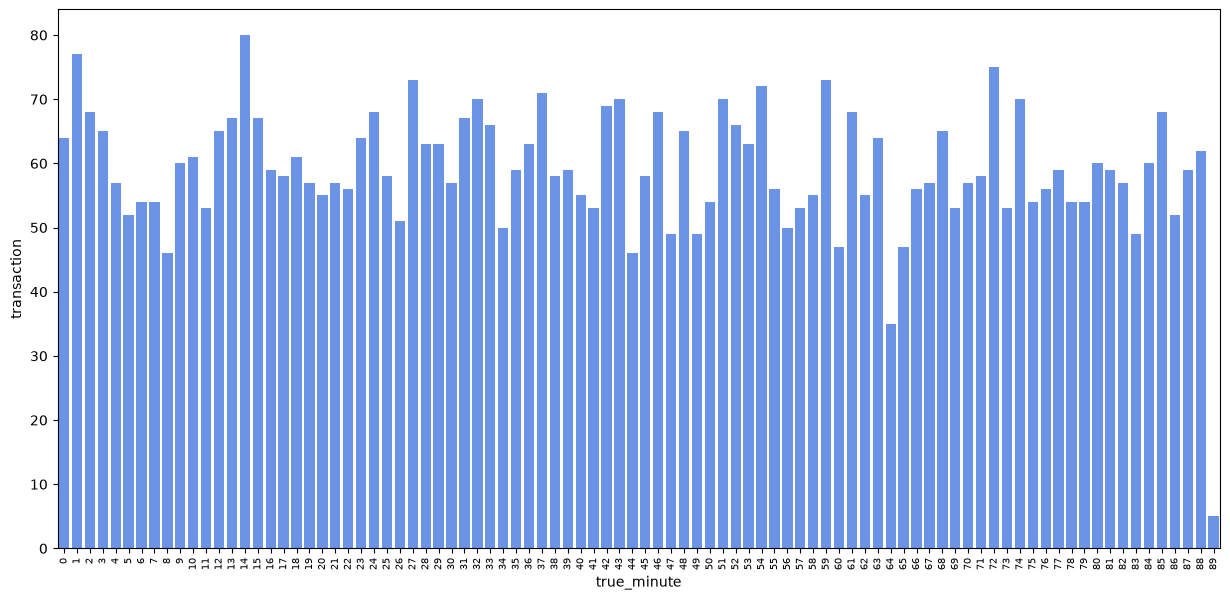

In [19]:
fig_new_transaction = plt.figure(figsize=(15,7))
sns.barplot(x=new_transaction.true_minute, y= new_transaction.transaction)
plt.xticks(fontsize = 7, rotation = 90)